<a href="https://colab.research.google.com/github/idkisma3l/TALLER02_ISI/blob/main/02_ebusiness_kpis_IsmaelSalazar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller: Auditoría de Desempeño para Negocios Digitales:

## Parte 1: Análisis de datos sintéticos

En esta parte vamos a analizar un dataset de transacciones y determinar si la estrategia de M-Commerce (App Móvil) es más rentable que el E-Commerce tradicional (Web Desktop).

Vamos a generar una base de datos aleatoria, que simula la salida de un TPS.

In [57]:
import pandas as pd
import numpy as np

# Generar datos simulados
data = {
    'ID_Transaccion': range(1001, 1051),
    'Canal': np.random.choice(['Web Desktop', 'App Móvil'], 50, p=[0.4, 0.6]),
    'Metodo_Pago': np.random.choice(['Tarjeta Crédito', 'PayPal', 'Transferencia'], 50),
    'Total_Venta': np.random.randint(20, 500, 50), # Ventas entre $20 y $500
    'Categoria': np.random.choice(['Electrónica', 'Moda', 'Hogar'], 50)
}

df = pd.DataFrame(data)

df

,ID_Transaccion,Canal,Metodo_Pago,Total_Venta,Categoria
0,1001,Web Desktop,Transferencia,261,Electrónica
1,1002,Web Desktop,Tarjeta Crédito,216,Electrónica
2,1003,Web Desktop,Transferencia,62,Hogar
3,1004,App Móvil,Transferencia,326,Moda
4,1005,App Móvil,PayPal,442,Electrónica
5,1006,Web Desktop,Transferencia,477,Electrónica
6,1007,App Móvil,Transferencia,157,Electrónica
7,1008,Web Desktop,Tarjeta Crédito,248,Electrónica
8,1009,App Móvil,Transferencia,311,Moda
9,1010,Web Desktop,PayPal,389,Hogar


### ¿Qué preguntas deberíamos plantearnos para obtener las respuestas que buscamos?

Buscamos saber cuál de las dos estrategias (**M-Commerce = App Móvil** o **E-Commerce = Web Desktop**) es la más rentable.

> **Nota:** en este dataset no tenemos costos ni utilidad neta, así que la rentabilidad se aproxima con ingresos y comportamiento comercial.

#### 4 KPIs propuestos para el MIS

1. **¿Qué canal genera más dinero en total?**  
   **KPI 1: Ingreso total por canal** = suma de `Total_Venta` por `Canal`.

2. **¿En qué canal se compra un monto mayor por transacción?**  
   **KPI 2: Ticket promedio por transacción** = promedio de `Total_Venta` por `Canal`.

3. **¿Qué estrategia mueve más volumen de ventas?**  
   **KPI 3: Número de transacciones por canal** = conteo de `ID_Transaccion` por `Canal`.

4. **¿Qué canal concentra más ingresos en la categoría de mayor valor?**  
   **KPI 4: Participación de la categoría líder** = ingreso de la categoría más rentable dentro de cada canal / ingreso total del canal.

In [66]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# =====================================================
# GENERACIÓN DEL DATASET TPS SIMULADO
# =====================================================

np.random.seed(42)

data = {
    'ID_Transaccion': range(1001, 1051),
    'Canal': np.random.choice(
        ['Web Desktop', 'App Móvil'],
        50,
        p=[0.4, 0.6]
    ),
    'Metodo_Pago': np.random.choice(
        ['Tarjeta Crédito', 'PayPal', 'Transferencia'],
        50
    ),
    'Total_Venta': np.random.randint(
        20,
        500,
        50
    ),
    'Categoria': np.random.choice(
        ['Electrónica', 'Moda', 'Hogar'],
        50
    )
}

df = pd.DataFrame(data)

# =====================================================
# KPI 1.1 — Ingreso Total por Canal
# ¿Qué canal genera más dinero en total?
# =====================================================

ventas_canal = (
    df.groupby('Canal')['Total_Venta']
    .sum()
)

# =====================================================
# KPI 1.2 — Ticket Promedio por Transacción
# ¿En qué canal se compra un monto mayor?
# =====================================================

ticket_promedio = (
    df.groupby('Canal')['Total_Venta']
    .mean()
)

# =====================================================
# KPI 1.3 — Número de Transacciones
# ¿Qué estrategia mueve más volumen?
# =====================================================

transacciones = (
    df.groupby('Canal')['ID_Transaccion']
    .count()
)

# =====================================================
# KPI 1.4 — Participación de la Categoría Líder
# ¿Qué canal concentra más ingresos en su
# categoría más rentable?
# =====================================================

participacion_categoria = (
    df.groupby(['Canal', 'Categoria'])['Total_Venta']
      .sum()
      .reset_index()
)

participacion = {}

for canal in df['Canal'].unique():

    total_canal = ventas_canal[canal]

    categoria_lider = (
        participacion_categoria[
            participacion_categoria['Canal'] == canal
        ]['Total_Venta']
        .max()
    )

    participacion[canal] = round(
        categoria_lider / total_canal * 100,
        2
    )

# =====================================================
# DASHBOARD MIS
# =====================================================

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "KPI 1.1 · Ingreso Total por Canal",
        "KPI 1.2 · Ticket Promedio por Transacción",
        "KPI 1.3 · Número de Transacciones",
        "KPI 1.4 · Participación de la Categoría Líder"
    )
)

# =====================================================
# KPI 1.1
# =====================================================

fig.add_trace(
    go.Bar(
        x=ventas_canal.index,
        y=ventas_canal.values,
        text=[f"${x:,.0f}" for x in ventas_canal.values],
        textposition='outside',
        marker_color=['#00E5FF', '#00FF9F']
    ),
    row=1,
    col=1
)

# =====================================================
# KPI 1.2
# =====================================================

fig.add_trace(
    go.Bar(
        x=ticket_promedio.index,
        y=ticket_promedio.values,
        text=[f"${x:.2f}" for x in ticket_promedio.values],
        textposition='outside',
        marker_color=['#FF6B6B', '#FFD93D']
    ),
    row=1,
    col=2
)

# =====================================================
# KPI 1.3
# =====================================================

fig.add_trace(
    go.Bar(
        x=transacciones.index,
        y=transacciones.values,
        text=transacciones.values,
        textposition='outside',
        marker_color=['#A66CFF', '#6CFFB8']
    ),
    row=2,
    col=1
)

# =====================================================
# KPI 1.4
# =====================================================

fig.add_trace(
    go.Bar(
        x=list(participacion.keys()),
        y=list(participacion.values()),
        text=[f"{x}%" for x in participacion.values()],
        textposition='outside',
        marker_color=['#FF9F1C', '#2EC4B6']
    ),
    row=2,
    col=2
)

# =====================================================
# FORMATO VISUAL
# =====================================================

fig.update_layout(
    template='plotly_dark',
    paper_bgcolor='#0d1117',
    plot_bgcolor='#161b22',
    height=750,
    width=1200,
    showlegend=False,
    title={
        'text':
        'Dashboard MIS: Rentabilidad M-Commerce vs E-Commerce',
        'x': 0.5,
        'font': {
            'size': 22
        }
    }
)

fig.update_xaxes(
    showgrid=False,
    title_font=dict(size=12)
)

fig.update_yaxes(
    gridcolor='#2d333b'
)

fig.show()

# =====================================================
# RESUMEN EJECUTIVO
# =====================================================

print("\n=========== RESUMEN DE KPIs ===========")

print("\nKPI 1.1 - Ingreso Total por Canal")
print(ventas_canal)

print("\nKPI 1.2 - Ticket Promedio")
print(ticket_promedio.round(2))

print("\nKPI 1.3 - Número de Transacciones")
print(transacciones)

print("\nKPI 1.4 - Participación de la Categoría Líder (%)")
print(participacion)


=========== RESUMEN DE KPIs ===========

KPI 1.1 - Ingreso Total por Canal
Canal
App Móvil      6779
Web Desktop    5549
Name: Total_Venta, dtype: int64

KPI 1.2 - Ticket Promedio
Canal
App Móvil      260.73
Web Desktop    231.21
Name: Total_Venta, dtype: float64

KPI 1.3 - Número de Transacciones
Canal
App Móvil      26
Web Desktop    24
Name: ID_Transaccion, dtype: int64

KPI 1.4 - Participación de la Categoría Líder (%)
{'Web Desktop': np.float64(46.96), 'App Móvil': np.float64(43.21)}


## Parte 2: KPIs para E-Commerce

Para esta parte vamos a utilizar los datos qu se encuentran en el repositorio en `/data/ecommerce.zip`

In [59]:
import pandas as pd

In [60]:
data = pd.read_csv("Train.csv")
data

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [61]:
# Dataset principal de e-commerce (electrónica)
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/e-commerce.csv"
try:
    ecom = pd.read_csv(url)
except Exception:
    # Dataset embebido de respaldo con las columnas originales del taller
    np.random.seed(42)
    n = 10999
    ecom = pd.DataFrame({
        'ID': range(1, n+1),
        'Warehouse_block': np.random.choice(list('ABCDF'), n),
        'Mode_of_Shipment': np.random.choice(['Ship', 'Flight', 'Road'], n, p=[0.6, 0.25, 0.15]),
        'Customer_care_calls': np.random.randint(1, 8, n),
        'Customer_rating': np.random.randint(1, 6, n),
        'Cost_of_the_product': np.random.randint(96, 310, n),
        'Prior_purchases': np.random.randint(2, 7, n),
        'Product_importance': np.random.choice(['low', 'medium', 'high'], n, p=[0.4, 0.4, 0.2]),
        'Gender': np.random.choice(['M', 'F'], n),
        'Discount_offered': np.random.randint(0, 66, n),
        'Weight_in_gms': np.random.randint(1000, 7100, n),
        'Reached.on.Time_Y.N': np.random.choice([0, 1], n)
    })

print(f"Dataset cargado: {ecom.shape[0]} filas × {ecom.shape[1]} columnas")
ecom.head()

Dataset cargado: 10999 filas × 12 columnas


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,2,3,115,6,low,F,57,5782,1
1,2,F,Ship,1,4,107,3,low,M,55,6169,1
2,3,C,Flight,3,2,180,2,high,F,51,3331,1
3,4,F,Ship,6,2,144,2,low,F,27,2822,1
4,5,F,Ship,4,2,275,5,high,F,23,5296,1


In [62]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Paleta neon dark ──────────────────────────────────────────────────────────
BG      = '#0d0d0d'
PANEL   = '#1a1a2e'
NEON    = ['#00f5ff', '#ff2079', '#39ff14', '#ff9500', '#bf5fff', '#ffec00']
GRID    = '#2a2a4a'
TEXT    = '#e0e0e0'

def neon_style(fig, axes_list):
    """Aplica el tema dark+neon a una figura y sus ejes."""
    fig.patch.set_facecolor(BG)
    for ax in axes_list:
        ax.set_facecolor(PANEL)
        ax.tick_params(colors=TEXT, labelsize=9)
        ax.xaxis.label.set_color(TEXT)
        ax.yaxis.label.set_color(TEXT)
        ax.title.set_color(TEXT)
        for spine in ax.spines.values():
            spine.set_edgecolor(GRID)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'{x:,.0f}'))

print("✅ Configuración visual lista.")

✅ Configuración visual lista.


### 1. KPIs de Gestión de Logística y Operaciones (Shipment & Warehouse)

Permiten medir la eficiencia en la distribución de los productos electrónicos.

1.1. **Costo Promedio de Envío por Modo de Transporte (Mode of Shipment):** Ayuda a evaluar qué canales (Barco, Avión, Carretera) representan un mayor impacto financiero en relación con el peso del producto.

1.2. **Volumen de Ocupación por Bloque de Bodega (Warehouse Block):** Porcentaje o cantidad total de productos/peso administrados en cada bloque (A, B, C, D, E) para entender la carga operativa de la infraestructura.

1.3. **Peso Promedio del Producto por Modo de Envío:** Para analizar si se está optimizando la logística (ej. si los productos más pesados se están enviando por barco o si se está gastando de más enviándolos por avión).

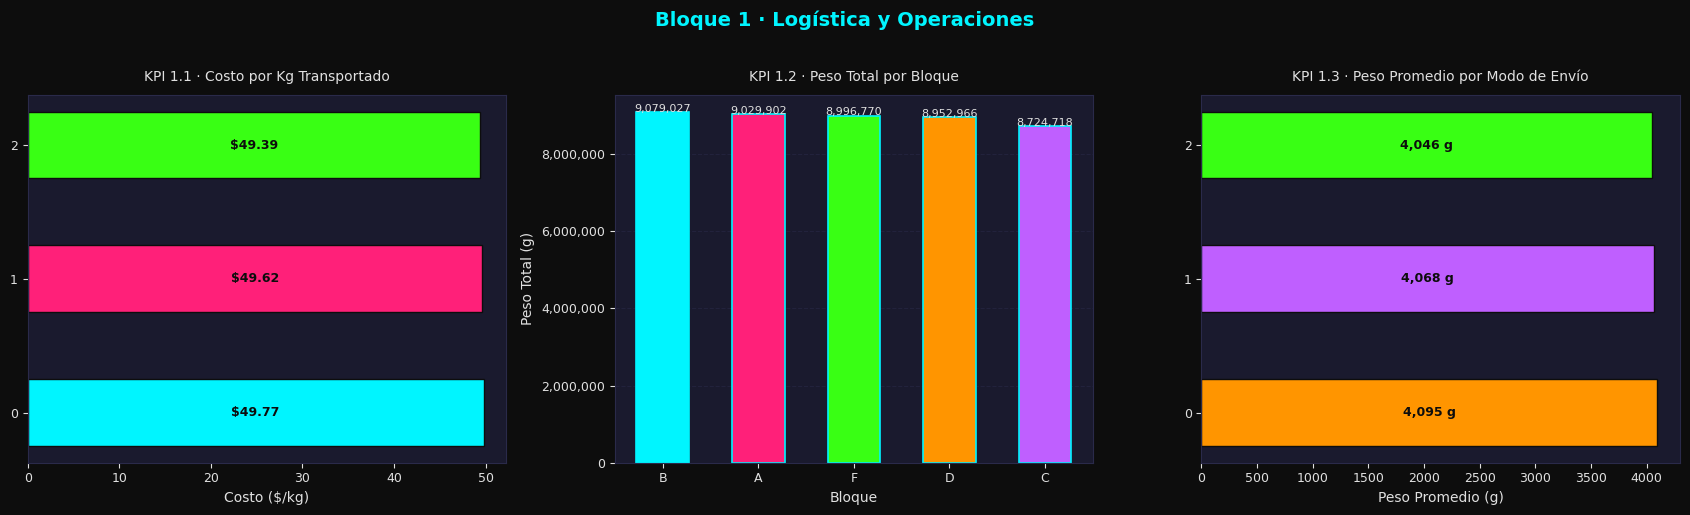

KPIs de Logística generados.


In [63]:
# ─────────────────────────────────────────────────────────────────────────────
# KPI 1.1 — Costo Promedio por Kg según Modo de Transporte
# KPI 1.2 — Volumen de Ocupación por Bloque de Bodega
# KPI 1.3 — Peso Promedio del Producto por Modo de Envío
# ─────────────────────────────────────────────────────────────────────────────

# ── Cálculos ─────────────────────────────────────────────────────────────────

# KPI 1.1
kpi_1_1 = (
    ecom.groupby('Mode_of_Shipment')
    .apply(
        lambda x: x['Cost_of_the_product'].sum() /
                  (x['Weight_in_gms'].sum() / 1000)
    )
    .sort_values(ascending=False)
)

# KPI 1.2
kpi_1_2 = (
    ecom.groupby('Warehouse_block')['Weight_in_gms']
    .sum()
    .sort_values(ascending=False)
)

# KPI 1.3
kpi_1_3 = (
    ecom.groupby('Mode_of_Shipment')['Weight_in_gms']
    .mean()
    .sort_values(ascending=False)
)

# ── Figura ───────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

fig.suptitle(
    'Bloque 1 · Logística y Operaciones',
    fontsize=14,
    color=NEON[0],
    fontweight='bold',
    y=1.02
)

neon_style(fig, axes)

# ─────────────────────────────────────────────────────────────────────────────
# KPI 1.1
# ─────────────────────────────────────────────────────────────────────────────

ax = axes[0]

bars = ax.barh(
    kpi_1_1.index,
    kpi_1_1.values,
    color=NEON[:len(kpi_1_1)],
    edgecolor=BG,
    height=0.5
)

ax.set_title(
    'KPI 1.1 · Costo por Kg Transportado',
    fontsize=10,
    pad=10
)

ax.set_xlabel('Costo ($/kg)')

for bar, val in zip(bars, kpi_1_1.values):
    ax.text(
        bar.get_width()*0.5,
        bar.get_y()+bar.get_height()/2,
        f'${val:.2f}',
        va='center',
        ha='center',
        color=BG,
        fontweight='bold',
        fontsize=9
    )

# ─────────────────────────────────────────────────────────────────────────────
# KPI 1.2
# ─────────────────────────────────────────────────────────────────────────────

ax = axes[1]

bars2 = ax.bar(
    kpi_1_2.index,
    kpi_1_2.values,
    color=NEON[:len(kpi_1_2)],
    edgecolor=NEON[0],
    linewidth=1.2,
    width=0.55
)

ax.set_title(
    'KPI 1.2 · Peso Total por Bloque',
    fontsize=10,
    pad=10
)

ax.set_xlabel('Bloque')
ax.set_ylabel('Peso Total (g)')

ax.yaxis.grid(True, color=GRID, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

for bar in bars2:
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+5000,
        f'{bar.get_height():,.0f}',
        ha='center',
        color=TEXT,
        fontsize=8
    )

# ─────────────────────────────────────────────────────────────────────────────
# KPI 1.3
# ─────────────────────────────────────────────────────────────────────────────

ax = axes[2]

palette = [NEON[3], NEON[4], NEON[2]]

bars3 = ax.barh(
    kpi_1_3.index,
    kpi_1_3.values,
    color=palette[:len(kpi_1_3)],
    edgecolor=BG,
    height=0.5
)

ax.set_title(
    'KPI 1.3 · Peso Promedio por Modo de Envío',
    fontsize=10,
    pad=10
)

ax.set_xlabel('Peso Promedio (g)')

for bar, val in zip(bars3, kpi_1_3.values):
    ax.text(
        val*0.5,
        bar.get_y()+bar.get_height()/2,
        f'{val:,.0f} g',
        va='center',
        ha='center',
        color=BG,
        fontweight='bold',
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    'kpi_bloque1_logistica.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=BG
)

plt.show()

print("KPIs de Logística generados.")

### 2. KPIs de Gestión Comercial y Financiera (Sales & Revenue)

Enfocados en el rendimiento del dinero, los descuentos y la estrategia de precios.

2.1. **Ingreso Total Bruto y Costo Promedio del Producto:** Suma y promedio de la variable `Cost of the product` para entender el ticket promedio de la tienda de electrónica.

2.2. **Porcentaje de Descuento Promedio Otorgado:** Evaluar el impacto de la estrategia de promociones (`Discount offered`) y si los descuentos altos realmente correlacionan con clientes de mayor prioridad o compras previas.

2.3. **Margen Teórico Relativo por Importancia del Producto:** Cruzar `Product importance` (Low, Medium, High) con el costo para ver si los productos catalogados como "alta importancia" son también los más costosos o los que reciben más descuentos.

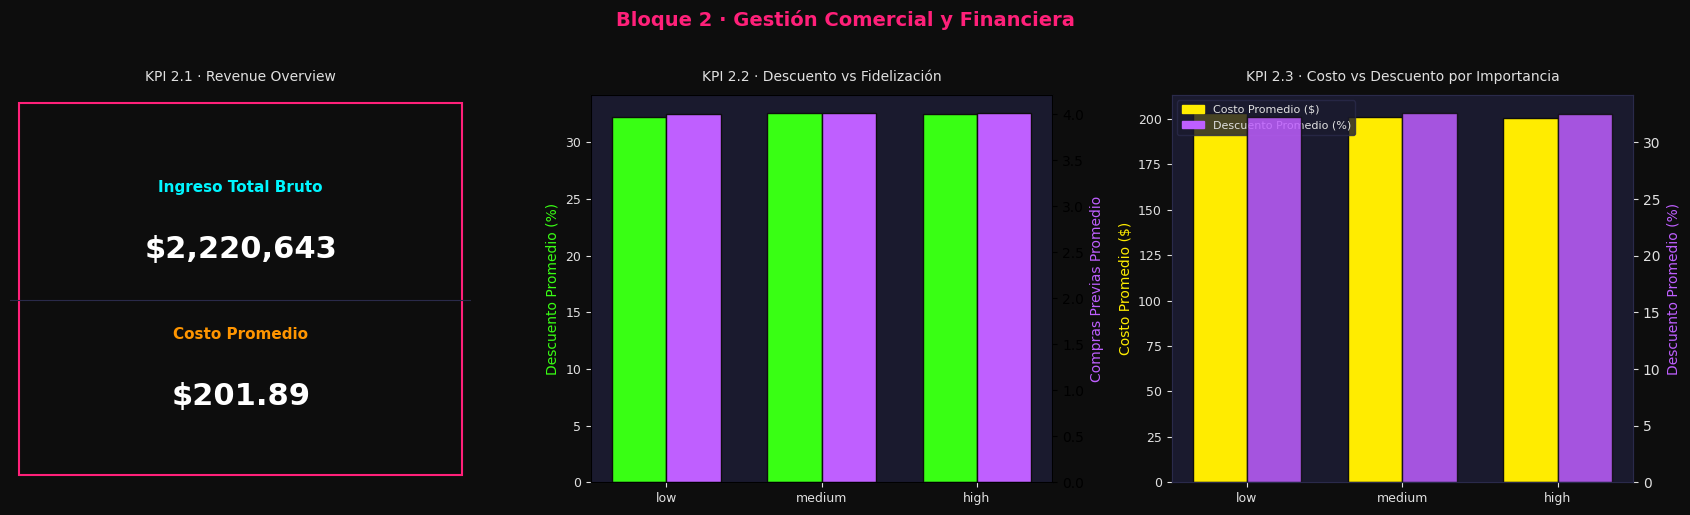

KPIs Comerciales y Financieros generados.


In [64]:
# ─────────────────────────────────────────────────────────────────────────────
# KPI 2.1 — Ingreso Total Bruto y Costo Promedio del Producto
# KPI 2.2 — Descuento Promedio y Compras Previas por Importancia
# KPI 2.3 — Costo Promedio vs Descuento por Importancia
# ─────────────────────────────────────────────────────────────────────────────

# ── Cálculos ─────────────────────────────────────────────────────────────────

# KPI 2.1
ingreso_total = ecom['Cost_of_the_product'].sum()
costo_promedio = ecom['Cost_of_the_product'].mean()

# KPI 2.2
orden_imp = ['low', 'medium', 'high']

kpi_2_2 = (
    ecom.groupby('Product_importance')
    .agg(
        Descuento_Promedio=('Discount_offered', 'mean'),
        Compras_Previas=('Prior_purchases', 'mean')
    )
    .reindex(orden_imp)
)

# KPI 2.3
kpi_2_3 = (
    ecom.groupby('Product_importance')
    .agg(
        Costo_Promedio=('Cost_of_the_product', 'mean'),
        Descuento_Promedio=('Discount_offered', 'mean')
    )
    .reindex(orden_imp)
)

# ── Figura ───────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

fig.suptitle(
    'Bloque 2 · Gestión Comercial y Financiera',
    fontsize=14,
    color=NEON[1],
    fontweight='bold',
    y=1.02
)

neon_style(fig, axes)

# ─────────────────────────────────────────────────────────────────────────────
# KPI 2.1 — Tarjetas Financieras
# ─────────────────────────────────────────────────────────────────────────────

ax = axes[0]

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

ax.set_title(
    'KPI 2.1 · Revenue Overview',
    fontsize=10,
    pad=10,
    color=TEXT
)

ax.text(
    0.5, 0.75,
    'Ingreso Total Bruto',
    ha='center',
    color=NEON[0],
    fontsize=11,
    fontweight='bold'
)

ax.text(
    0.5, 0.58,
    f'${ingreso_total:,.0f}',
    ha='center',
    color='white',
    fontsize=22,
    fontweight='bold'
)

ax.axhline(
    0.47,
    color=GRID,
    linewidth=0.8
)

ax.text(
    0.5, 0.37,
    'Costo Promedio',
    ha='center',
    color=NEON[3],
    fontsize=11,
    fontweight='bold'
)

ax.text(
    0.5, 0.20,
    f'${costo_promedio:,.2f}',
    ha='center',
    color='white',
    fontsize=22,
    fontweight='bold'
)

rect = plt.Rectangle(
    (0.02, 0.02),
    0.96,
    0.96,
    fill=False,
    edgecolor=NEON[1],
    linewidth=1.5,
    transform=ax.transAxes
)

ax.add_patch(rect)

# ─────────────────────────────────────────────────────────────────────────────
# KPI 2.2 — Descuento vs Compras Previas
# ─────────────────────────────────────────────────────────────────────────────

ax = axes[1]

x = range(len(kpi_2_2))
width = 0.35

ax.bar(
    [i - width/2 for i in x],
    kpi_2_2['Descuento_Promedio'],
    width=width,
    color=NEON[2],
    edgecolor=BG,
    label='Descuento (%)'
)

ax2 = ax.twinx()

ax2.bar(
    [i + width/2 for i in x],
    kpi_2_2['Compras_Previas'],
    width=width,
    color=NEON[4],
    edgecolor=BG,
    label='Compras Previas'
)

ax.set_xticks(list(x))
ax.set_xticklabels(orden_imp)

ax.set_title(
    'KPI 2.2 · Descuento vs Fidelización',
    fontsize=10,
    pad=10
)

ax.set_ylabel(
    'Descuento Promedio (%)',
    color=NEON[2]
)

ax2.set_ylabel(
    'Compras Previas Promedio',
    color=NEON[4]
)

# ─────────────────────────────────────────────────────────────────────────────
# KPI 2.3 — Costo vs Descuento
# ─────────────────────────────────────────────────────────────────────────────

ax = axes[2]

x = range(len(kpi_2_3))
width = 0.35

ax.bar(
    [i - width/2 for i in x],
    kpi_2_3['Costo_Promedio'],
    width=width,
    color=NEON[5],
    edgecolor=BG,
    label='Costo'
)

ax2b = ax.twinx()

ax2b.bar(
    [i + width/2 for i in x],
    kpi_2_3['Descuento_Promedio'],
    width=width,
    color=NEON[4],
    edgecolor=BG,
    alpha=0.85,
    label='Descuento'
)

ax.set_xticks(list(x))
ax.set_xticklabels(orden_imp)

ax.set_title(
    'KPI 2.3 · Costo vs Descuento por Importancia',
    fontsize=10,
    pad=10
)

ax.set_ylabel(
    'Costo Promedio ($)',
    color=NEON[5]
)

ax2b.set_ylabel(
    'Descuento Promedio (%)',
    color=NEON[4]
)

ax2b.tick_params(colors=TEXT)

for spine in ax2b.spines.values():
    spine.set_edgecolor(GRID)

legend_items = [
    plt.Rectangle((0,0),1,1,color=NEON[5]),
    plt.Rectangle((0,0),1,1,color=NEON[4])
]

ax.legend(
    legend_items,
    ['Costo Promedio ($)', 'Descuento Promedio (%)'],
    loc='upper left',
    facecolor=PANEL,
    edgecolor=GRID,
    labelcolor=TEXT,
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    'kpi_bloque2_comercial.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=BG
)

plt.show()

print("KPIs Comerciales y Financieros generados.")

### 3. KPIs de Experiencia y Fidelización del Cliente (Customer Experience - CX)

Diseñados para evaluar la satisfacción y la carga de soporte post-venta.

3.1. **Índice de Satisfacción del Cliente (CSAT) Promedio:** El promedio de la variable `Customer rating` (escala 1 a 5). Se puede segmentar por género o por bloque de bodega para ver si hay anomalías.

3.2. **Tasa de Retención / Clientes Recurrentes:** Analizar la distribución de `Prior purchases` para determinar qué porcentaje de la base de datos son clientes nuevos (0-1 compras previas) vs. clientes fidelizados (2 o más compras).

3.3. **Carga de Soporte por Cliente (Customer Care Calls):** Promedio de llamadas de consulta realizadas. Permite analizar si a mayor costo del producto o menores calificaciones, aumentan las llamadas de reclamo.

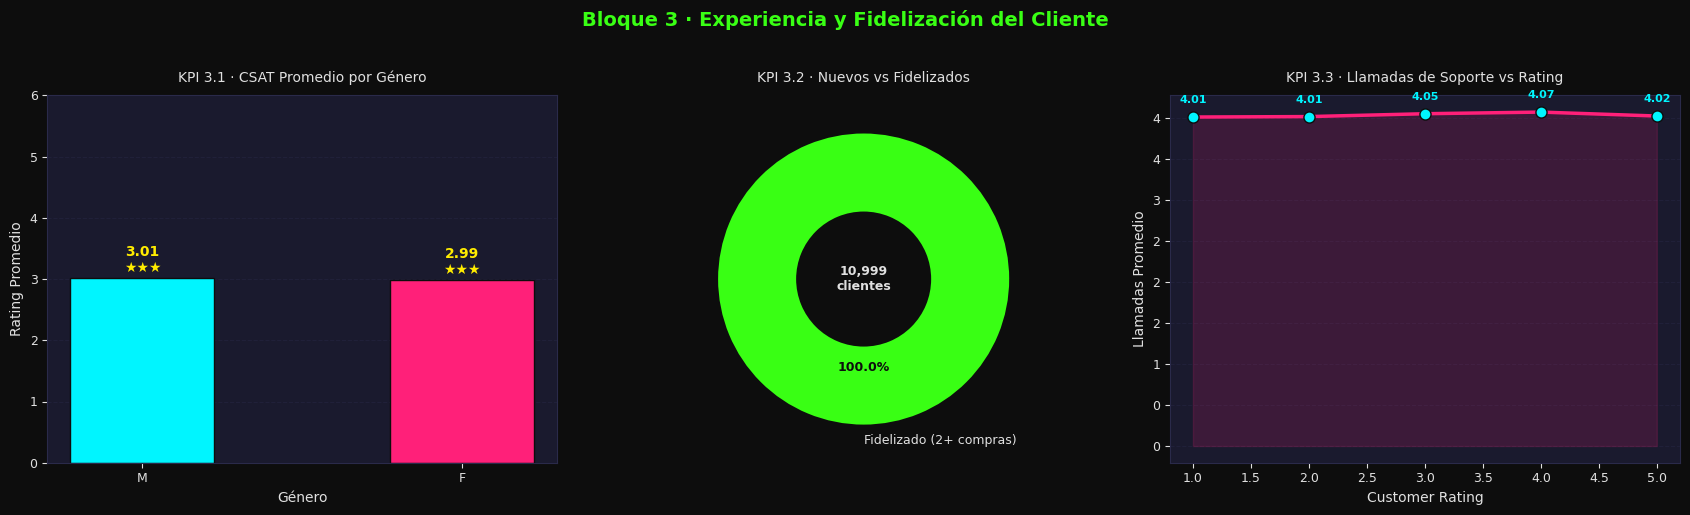

KPIs de Customer Experience generados.


In [65]:
# ─────────────────────────────────────────────────────────────────────────────
# KPI 3.1 — CSAT Promedio por Género
# KPI 3.2 — Tasa de Retención: Nuevos vs Fidelizados
# KPI 3.3 — Llamadas de Soporte vs Calificación del Cliente
# ─────────────────────────────────────────────────────────────────────────────

# ── Cálculos ─────────────────────────────────────────────────────────────────

# KPI 3.1
kpi_3_1 = (
    ecom.groupby('Gender')['Customer_rating']
    .mean()
    .sort_values(ascending=False)
)

# KPI 3.2
ecom['Segmento_Cliente'] = ecom['Prior_purchases'].apply(
    lambda x: 'Nuevo (0-1 compras)' if x <= 1
    else 'Fidelizado (2+ compras)'
)

kpi_3_2 = ecom['Segmento_Cliente'].value_counts()

# KPI 3.3
kpi_3_3 = (
    ecom.groupby('Customer_rating')['Customer_care_calls']
    .mean()
    .sort_index()
)

# ── Figura ───────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

fig.suptitle(
    'Bloque 3 · Experiencia y Fidelización del Cliente',
    fontsize=14,
    color=NEON[2],
    fontweight='bold',
    y=1.02
)

neon_style(fig, axes)

# ─────────────────────────────────────────────────────────────────────────────
# KPI 3.1 — CSAT por Género
# ─────────────────────────────────────────────────────────────────────────────

ax = axes[0]

colors_3_1 = [NEON[0], NEON[1]]

bars = ax.bar(
    kpi_3_1.index,
    kpi_3_1.values,
    color=colors_3_1[:len(kpi_3_1)],
    edgecolor=BG,
    width=0.45
)

ax.set_title(
    'KPI 3.1 · CSAT Promedio por Género',
    fontsize=10,
    pad=10
)

ax.set_xlabel('Género')
ax.set_ylabel('Rating Promedio')
ax.set_ylim(0, 6)

ax.yaxis.grid(True, color=GRID, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

for bar, val in zip(bars, kpi_3_1.values):
    stars = '★' * round(val)

    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.1,
        f'{val:.2f}\n{stars}',
        ha='center',
        color=NEON[5],
        fontsize=10,
        fontweight='bold'
    )

# ─────────────────────────────────────────────────────────────────────────────
# KPI 3.2 — Donut Clientes Nuevos vs Fidelizados
# ─────────────────────────────────────────────────────────────────────────────

ax = axes[1]

colors_3_2 = [NEON[2], NEON[4]]

wedges, texts, autotexts = ax.pie(
    kpi_3_2.values,
    labels=kpi_3_2.index,
    autopct='%1.1f%%',
    colors=colors_3_2,
    startangle=90,
    wedgeprops={
        'width':0.55,
        'edgecolor':BG,
        'linewidth':2
    },
    textprops={
        'color':TEXT,
        'fontsize':9
    }
)

for at in autotexts:
    at.set_color(BG)
    at.set_fontweight('bold')

ax.text(
    0,
    0,
    f'{ecom.shape[0]:,}\nclientes',
    ha='center',
    va='center',
    color=TEXT,
    fontsize=9,
    fontweight='bold'
)

ax.set_title(
    'KPI 3.2 · Nuevos vs Fidelizados',
    fontsize=10,
    pad=10
)

# ─────────────────────────────────────────────────────────────────────────────
# KPI 3.3 — Soporte vs Calificación
# ─────────────────────────────────────────────────────────────────────────────

ax = axes[2]

ax.plot(
    kpi_3_3.index,
    kpi_3_3.values,
    color=NEON[1],
    linewidth=2.5,
    marker='o',
    markerfacecolor=NEON[0],
    markeredgecolor=BG,
    markersize=8
)

ax.fill_between(
    kpi_3_3.index,
    kpi_3_3.values,
    alpha=0.15,
    color=NEON[1]
)

ax.set_title(
    'KPI 3.3 · Llamadas de Soporte vs Rating',
    fontsize=10,
    pad=10
)

ax.set_xlabel('Customer Rating')
ax.set_ylabel('Llamadas Promedio')

ax.yaxis.grid(True, color=GRID, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

for x, y in zip(kpi_3_3.index, kpi_3_3.values):
    ax.annotate(
        f'{y:.2f}',
        xy=(x, y),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        color=NEON[0],
        fontsize=8,
        fontweight='bold'
    )

plt.tight_layout()

plt.savefig(
    'kpi_bloque3_cx.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=BG
)

plt.show()

print("KPIs de Customer Experience generados.")